In [1]:
!pip install xgboost

In [2]:
!pip install kagglehub

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Setting Kaggle Credentials (dari notebook lama Anda)
os.environ['KAGGLE_USERNAME'] = 'muhammadyogaisnaeni'
os.environ['KAGGLE_KEY'] = 'bf6873ff2e9847adefe62b75047f2eb0'

path = kagglehub.competition_download('titanic')
print("Path to competition files:", path)

train_df = pd.read_csv(os.path.join(path, 'train.csv'))
test_df = pd.read_csv(os.path.join(path, 'test.csv'))

# Simpan PassengerId untuk submission Kaggle di akhir
test_passenger_ids = test_df['PassengerId'].values


100%|██████████| 34.1k/34.1k [00:00<00:00, 16.4MB/s]

Extracting files...
Path to competition files: /root/.cache/kagglehub/competitions/titanic


/tmp/ipykernel_7328/1056417546.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=train_df, palette='viridis')
/tmp/ipykernel_7328/1056417546.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=train_df, palette='viridis')


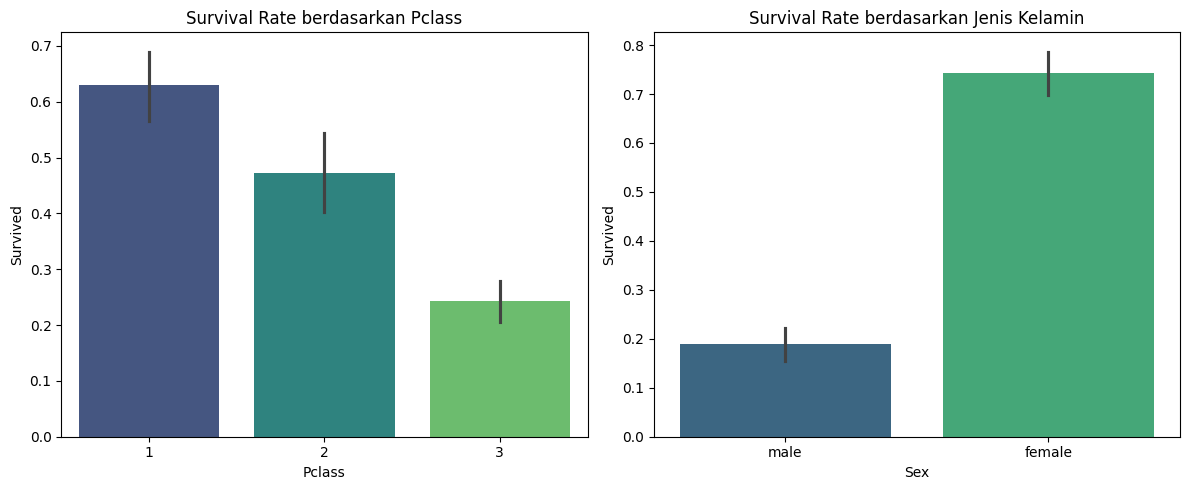

Missing values in Train:
 Age         177
Cabin       687
Embarked      2
dtype: int64


In [4]:
# --- EDA (Sesuai Panduan) ---
plt.figure(figsize=(12, 5))

# 1. Survival Rate berdasarkan Pclass
plt.subplot(1, 2, 1)
sns.barplot(x='Pclass', y='Survived', data=train_df, palette='viridis')
plt.title('Survival Rate berdasarkan Pclass')

# 2. Survival Rate berdasarkan Sex
plt.subplot(1, 2, 2)
sns.barplot(x='Sex', y='Survived', data=train_df, palette='viridis')
plt.title('Survival Rate berdasarkan Jenis Kelamin')

plt.tight_layout()
plt.show()

print("Missing values in Train:\n", train_df.isnull().sum()[train_df.isnull().sum() > 0])


In [5]:
# Check missing values
print("Missing values in train data:")
print(train_df.isnull().sum())
print("\nMissing values in test data:")
print(test_df.isnull().sum())

# Percentage of missing values
print("\nPercentage of missing values in train data:")
print((train_df.isnull().sum() / len(train_df)) * 100)
print("\nPercentage of missing values in test data:")
print((test_df.isnull().sum() / len(test_df)) * 100)

Missing values in train data:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values in test data:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Percentage of missing values in train data:
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

Percentage of missing values in test data:
PassengerId     0.000000
Pclass          0.000000
Name            0.00000

In [6]:
# Fill Age with median
train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
test_df['Age'].fillna(train_df['Age'].median(), inplace=True)  # use train median for test

# Fill Embarked with mode
train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)
test_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)

# Fill Fare in test with median
test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)

# Drop Cabin
train_df.drop('Cabin', axis=1, inplace=True)
test_df.drop('Cabin', axis=1, inplace=True)

print("Missing values after filling - Train:", train_df.isnull().sum().sum())
print("Test:", test_df.isnull().sum().sum())
print("\nTrain shape:", train_df.shape)
print("Test shape:", test_df.shape)


Missing values after filling - Train: 0
Test: 0

Train shape: (891, 11)
Test shape: (418, 10)


/tmp/ipykernel_7328/4273481409.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
/tmp/ipykernel_7328/4273481409.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

def perform_feature_engineering(df, is_train=True, age_medians=None, fare_median=None, mode_embarked=None):
    df = df.copy()

    # 1. Ekstrak Title (Tambahkan 'r' di depan string untuk Regex)
    if 'Name' in df.columns:
        df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
        df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
        df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
        df['Title'] = df['Title'].replace('Mme', 'Mrs')

    # 2. Ekstrak Deck dari Cabin (A, B, C, dsb)
    # Jika kolom Cabin sudah terlanjur dihapus di cell sebelumnya, paksa jadi 'U'
    if 'Cabin' in df.columns:
        df['Deck'] = df['Cabin'].apply(lambda x: x[0] if pd.notnull(x) else 'U')
    else:
        df['Deck'] = 'U'

    # 3. Family Size & IsAlone
    if 'SibSp' in df.columns and 'Parch' in df.columns:
        df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
        df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # 4. Imputasi Age
    if is_train:
        age_medians = df.groupby(['Title', 'Pclass'])['Age'].median()

    def fill_age(row):
        if pd.isnull(row['Age']):
            try:
                return age_medians[row['Title'], row['Pclass']]
            except:
                return df['Age'].median()
        return row['Age']

    if 'Age' in df.columns:
        df['Age'] = df.apply(fill_age, axis=1)
        # 5. Binning Age
        df['AgeBin'] = pd.qcut(df['Age'], 4, labels=False)

    # Imputasi Fare & Embarked
    if is_train:
        fare_median = df['Fare'].median() if 'Fare' in df.columns else 0
        mode_embarked = df['Embarked'].mode()[0] if 'Embarked' in df.columns else 'S'

    if 'Fare' in df.columns:
        df['Fare'] = df['Fare'].fillna(fare_median)
        df['FareBin'] = pd.qcut(df['Fare'], 4, labels=False, duplicates='drop')

    if 'Embarked' in df.columns:
        df['Embarked'] = df['Embarked'].fillna(mode_embarked)

    # Hapus kolom yang tidak dipakai lagi (errors='ignore' akan mencegah error jika kolom sudah tidak ada)
    cols_to_drop = ['Name', 'Ticket', 'Cabin', 'PassengerId', 'Age', 'Fare']
    df = df.drop(cols_to_drop, axis=1, errors='ignore')

    return df, age_medians, fare_median, mode_embarked

# --- Terapkan Feature Engineering ---
# PENTING: Jika data error, sangat disarankan me-RUN ULANG dari CELL 1
# agar train_df dan test_df kembali fresh dari CSV.
train_processed, age_meds, fare_med, mode_emb = perform_feature_engineering(train_df, is_train=True)
test_processed, _, _, _ = perform_feature_engineering(test_df, is_train=False, age_medians=age_meds, fare_median=fare_med, mode_embarked=mode_emb)

# Encoding Kategorikal
le_sex = LabelEncoder()
train_processed['Sex'] = le_sex.fit_transform(train_processed['Sex'])
test_processed['Sex'] = le_sex.transform(test_processed['Sex'])

# One Hot Encoding
train_encoded = pd.get_dummies(train_processed, columns=['Embarked', 'Title', 'Deck'])
test_encoded = pd.get_dummies(test_processed, columns=['Embarked', 'Title', 'Deck'])

# Pastikan kolom train dan test sejajar
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

X = train_encoded.drop('Survived', axis=1)
y = train_encoded['Survived']

# --- SPLIT DATA KONSISTEN (Random Seed = 42) ---
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
test_scaled = scaler.transform(test_encoded.drop('Survived', axis=1, errors='ignore'))

print("Feature Engineering Selesai! Jumlah fitur:", X_train.shape[1])


Feature Engineering Selesai! Jumlah fitur: 17


In [8]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

print("--- Training Random Forest ---")
rf_param = {'n_estimators': [100, 200], 'max_depth': [5, 10, None]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param, cv=5, scoring='accuracy')
rf_grid.fit(X_train_scaled, y_train)

best_rf = rf_grid.best_estimator_
rf_preds = best_rf.predict(X_val_scaled)

print("--- Training XGBoost ---")
xgb_param = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5]}
xgb_grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), xgb_param, cv=5, scoring='accuracy')
xgb_grid.fit(X_train_scaled, y_train)

best_xgb = xgb_grid.best_estimator_
xgb_preds = best_xgb.predict(X_val_scaled)

def evaluate(name, y_true, y_pred):
    print(f"\n[{name}] Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(classification_report(y_true, y_pred))

evaluate("Random Forest", y_val, rf_preds)
evaluate("XGBoost", y_val, xgb_preds)


--- Training Random Forest ---
--- Training XGBoost ---

[Random Forest] Accuracy: 0.8324
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.83      0.83      0.83       179


[XGBoost] Accuracy: 0.8212
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Konversi data ke PyTorch Tensors
X_tr_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_tr_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_v_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_v_t = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)

# Arsitektur MLP
class TabularMLP(nn.Module):
    def __init__(self, input_dim):
        super(TabularMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.4), # Regularisasi ketat untuk data kecil
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Set random seed torch untuk reproducibility (Penting!)
torch.manual_seed(42)

mlp_model = TabularMLP(X_train.shape[1])
criterion = nn.BCELoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.005, weight_decay=1e-4) # L2 Regularization

print("Training PyTorch MLP...")
epochs = 150
best_val_loss = float('inf')
patience, patience_counter = 15, 0
best_weights = None

for epoch in range(epochs):
    mlp_model.train()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        out = mlp_model(batch_X)
        loss = criterion(out, batch_y)
        loss.backward()
        optimizer.step()

    # Validation
    mlp_model.eval()
    with torch.no_grad():
        val_out = mlp_model(X_v_t)
        val_loss = criterion(val_out, y_v_t).item()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = mlp_model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# Load best weights
mlp_model.load_state_dict(best_weights)
mlp_model.eval()
with torch.no_grad():
    mlp_preds_prob = mlp_model(X_v_t).numpy()
    mlp_preds = (mlp_preds_prob > 0.5).astype(int).flatten()

evaluate("PyTorch MLP", y_val, mlp_preds)


Training PyTorch MLP...
Early stopping at epoch 33

[PyTorch MLP] Accuracy: 0.8101
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       105
           1       0.81      0.70      0.75        74

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



In [10]:
# --- ERROR ANALYSIS ---
# Kita cari data validasi dimana model XGBoost (sebagai contoh konvensional yang tangguh) salah menebak
X_val_original = train_df.iloc[X_val.index] # Ambil data asli sebelum di-scaling untuk kemudahan interpretasi
errors = X_val_original[y_val != xgb_preds]

print(f"Jumlah prediksi salah (XGBoost): {len(errors)} dari {len(y_val)} data validasi.")
print("Contoh 3 penumpang yang salah diprediksi:")
display(errors[['Pclass', 'Sex', 'Age', 'Fare', 'Survived']].head(3))

# --- KESIMPULAN SINGKAT TRADE-OFF ---
print("\n--- ANALISIS TRADE-OFF ---")
print("Sesuai panduan, ML konvensional (terutama XGBoost/RF) umumnya memberikan hasil yang")
print("sangat kompetitif bahkan seringkali MENGUNGGULI Deep Learning (MLP) pada dataset ")
print("sekecil ini (~900 baris). Model DL cenderung mudah overfit tanpa regularization ekstra, ")
print("dan pelatihan DL butuh kalibrasi manual (epoch/patience). Sebaliknya, XGBoost sangat ")
print("efisien dalam menangkap pola tabular non-linear dan tidak terlalu butuh preprocessing ekstrem.")


Jumlah prediksi salah (XGBoost): 32 dari 179 data validasi.
Contoh 3 penumpang yang salah diprediksi:


,Pclass,Sex,Age,Fare,Survived
621,1,male,42.0,52.5542,1
447,1,male,34.0,26.5500,1
673,2,male,31.0,13.0000,1



--- ANALISIS TRADE-OFF ---
Sesuai panduan, ML konvensional (terutama XGBoost/RF) umumnya memberikan hasil yang
sangat kompetitif bahkan seringkali MENGUNGGULI Deep Learning (MLP) pada dataset 
sekecil ini (~900 baris). Model DL cenderung mudah overfit tanpa regularization ekstra, 
dan pelatihan DL butuh kalibrasi manual (epoch/patience). Sebaliknya, XGBoost sangat 
efisien dalam menangkap pola tabular non-linear dan tidak terlalu butuh preprocessing ekstrem.


### Leaderboard Model Metrics

In [11]:
from sklearn.metrics import accuracy_score
import pandas as pd

# Calculate accuracy for each model
rf_accuracy = accuracy_score(y_val, rf_preds)
xgb_accuracy = accuracy_score(y_val, xgb_preds)
mlp_accuracy = accuracy_score(y_val, mlp_preds)

# Create a DataFrame for the leaderboard
leaderboard = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'PyTorch MLP'],
    'Accuracy': [rf_accuracy, xgb_accuracy, mlp_accuracy]
})

# Sort the leaderboard by accuracy in descending order
leaderboard = leaderboard.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("Leaderboard Model Terbaik:")
display(leaderboard)

Leaderboard Model Terbaik:


,Model,Accuracy
0,Random Forest,0.832402
1,XGBoost,0.821229
2,PyTorch MLP,0.810056
